<a href="https://colab.research.google.com/github/ayaz-ali-36/Machine-Learning/blob/main/Practise-pipeline/Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier

from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, fbeta_score, roc_curve, auc

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [28]:
df = pd.read_csv("/content/data.csv")

print(df.shape)
print(df.head())

(294, 14)
   age  sex  cp trestbps chol fbs restecg thalach exang  oldpeak slope ca  \
0   28    1   2      130  132   0       2     185     0      0.0     ?  ?   
1   29    1   2      120  243   0       0     160     0      0.0     ?  ?   
2   29    1   2      140    ?   0       0     170     0      0.0     ?  ?   
3   30    0   1      170  237   0       1     170     0      0.0     ?  ?   
4   31    0   2      100  219   0       1     150     0      0.0     ?  ?   

  thal  num         
0    ?           0  
1    ?           0  
2    ?           0  
3    6           0  
4    ?           0  


In [29]:
df.columns=df.columns.str.strip()
print(df.columns.tolist())
df=df.replace('?',np.nan)
print(df.isnull().sum())
print(df['num'].value_counts())
print(f"{df['num'].mean():.1%}")
print(df.dtypes)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64
num
0    188
1    106
Name: count, dtype: int64
36.1%
age           int64
sex           int64
cp            int64
trestbps     object
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
num           int64
dtype: object


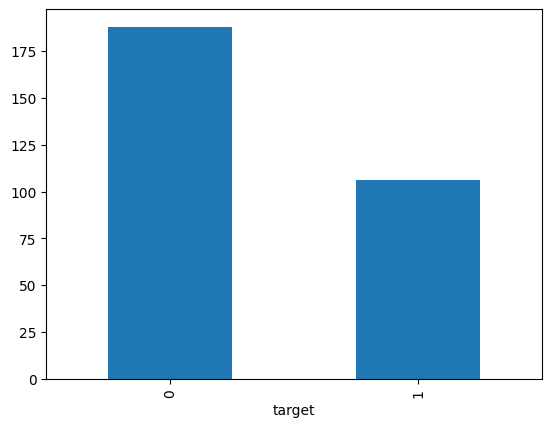

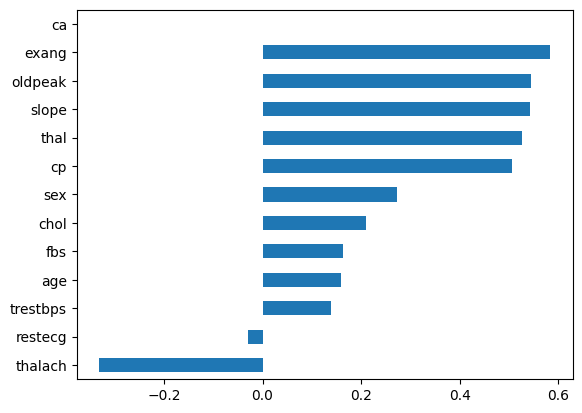

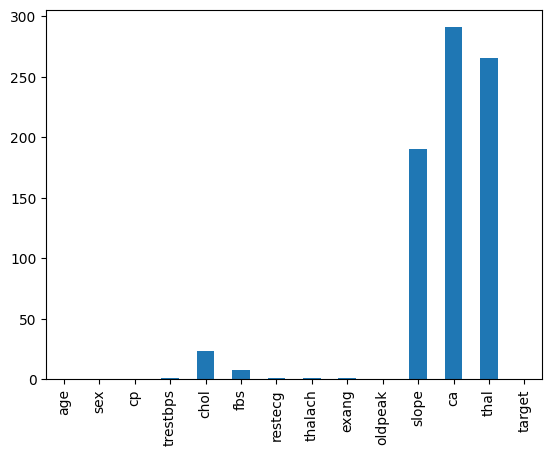

In [43]:
df['target'].value_counts().plot(kind='bar')
plt.show()

df.corr()['target'].drop('target')\
  .sort_values().plot(kind='barh')
plt.show()


df.isnull().sum().plot(kind='bar')
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (235, 13)
Test:  (59, 13)


In [53]:



pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestClassifier(
                random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.81      0.81      0.81        21

    accuracy                           0.86        59
   macro avg       0.85      0.85      0.85        59
weighted avg       0.86      0.86      0.86        59



In [54]:


param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth':    [3, 5, 7, None],
    'model__max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    pipeline, param_dist,
    n_iter=10, cv=5,
    scoring='recall',
    random_state=42)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best recall:", search.best_score_)

best = search.best_estimator_
print(classification_report(
    y_test, best.predict(X_test)))

Best params: {'model__n_estimators': 100, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best recall: 0.6941176470588235
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.81      0.81      0.81        21

    accuracy                           0.86        59
   macro avg       0.85      0.85      0.85        59
weighted avg       0.86      0.86      0.86        59



In [56]:



pipeline_smote = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=42)),
    ('model',   RandomForestClassifier(
                random_state=42))
])

pipeline_smote.fit(X_train, y_train)
y_pred_smote = pipeline_smote.predict(X_test)

print(classification_report(
    y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88        38
           1       0.80      0.76      0.78        21

    accuracy                           0.85        59
   macro avg       0.84      0.83      0.83        59
weighted avg       0.85      0.85      0.85        59



In [57]:
pipeline_cw = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   RandomForestClassifier(
                class_weight='balanced',
                random_state=42))
])

pipeline_cw.fit(X_train, y_train)
y_pred_cw = pipeline_cw.predict(X_test)

print("FULL COMPARISON")
print(f"{'Model':<20} {'Recall':>8} {'F1':>8}")
print("-"*38)
print(f"{'Default':<20} "
      f"{recall_score(y_test, y_pred):>8.3f} "
      f"{f1_score(y_test, y_pred):>8.3f}")
print(f"{'SMOTE':<20} "
      f"{recall_score(y_test, y_pred_smote):>8.3f} "
      f"{f1_score(y_test, y_pred_smote):>8.3f}")
print(f"{'Class Weights':<20} "
      f"{recall_score(y_test, y_pred_cw):>8.3f} "
      f"{f1_score(y_test, y_pred_cw):>8.3f}")

FULL COMPARISON
Model                  Recall       F1
--------------------------------------
Default                 0.810    0.810
SMOTE                   0.762    0.780
Class Weights           0.714    0.750


In [58]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imp = SimpleImputer(strategy='median')
sc  = StandardScaler()
X_tr = sc.fit_transform(imp.fit_transform(X_train))
X_te = sc.transform(imp.transform(X_test))


models = {
    'XGBoost':  XGBClassifier(random_state=42,
                eval_metric='logloss',
                verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
                random_state=42, verbose=-1)
}

from sklearn.metrics import f1_score, recall_score
for name, model in models.items():
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    print(f"{name}:")
    print(f"  F1:     {f1_score(y_test, pred):.3f}")
    print(f"  Recall: {recall_score(y_test, pred):.3f}")

XGBoost:
  F1:     0.634
  Recall: 0.619
LightGBM:
  F1:     0.600
  Recall: 0.571


In [60]:


joblib.dump(best, 'heart_pipeline.pkl')
print(" Model saved")

loaded = joblib.load('heart_pipeline.pkl')
pred   = loaded.predict(X_test)
print(f" Loaded model F1: "
      f"{f1_score(y_test, pred):.3f}")

 Model saved
 Loaded model F1: 0.810


In [61]:
!pip install shap --quiet

In [64]:
import shap
import numpy as np

# Extract steps
imputer    = pipeline.named_steps['imputer']
scaler     = pipeline.named_steps['scaler']
model_only = pipeline.named_steps['model']

# Transform test data
X_test_imputed   = imputer.transform(X_test)
X_test_scaled    = scaler.transform(X_test_imputed)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# New SHAP API
explainer   = shap.TreeExplainer(model_only)
explanation = explainer(X_test_scaled_df)

print(f"X_test shape:       {X_test_scaled_df.shape}")
print(f"SHAP values shape:  {explanation.values.shape}")
print("✅ Done")

X_test shape:       (59, 13)
SHAP values shape:  (59, 13, 2)
✅ Done


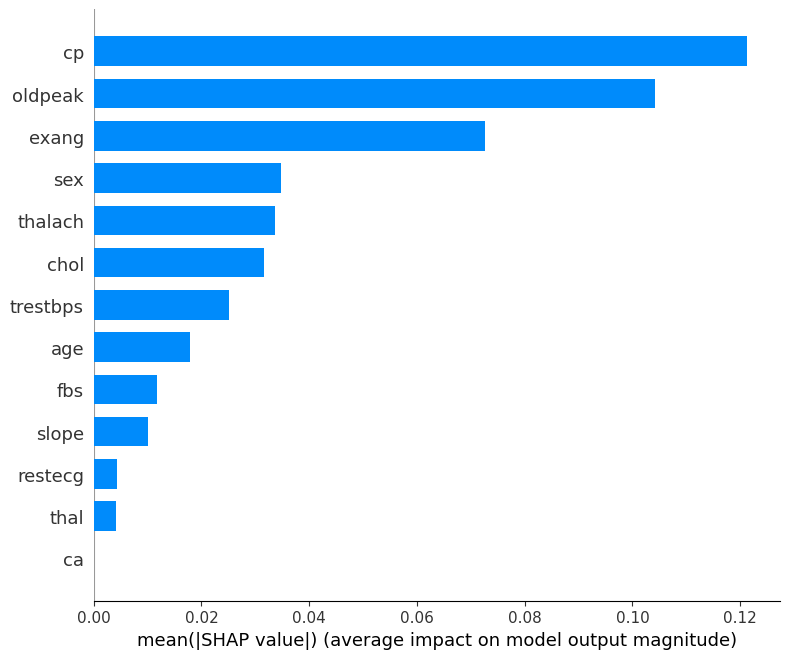

In [65]:
# Class 1 = Disease
shap.summary_plot(
    explanation.values[:, :, 1],
    X_test_scaled_df,
    plot_type='bar'
)

Patient 0:
Actual:    Healthy
Predicted: Healthy


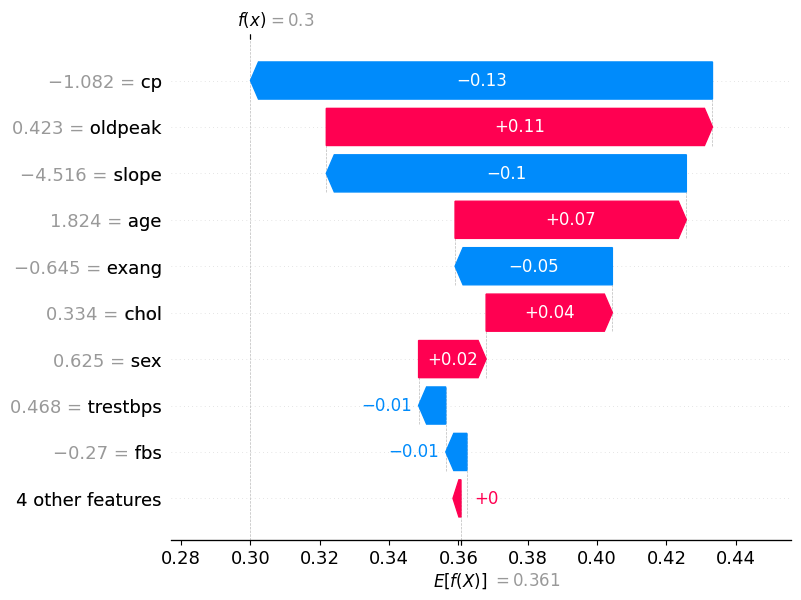

In [67]:
# Explain single patient
patient_idx = 0

print(f"Patient {patient_idx}:")
print(f"Actual:    {'Disease' if y_test.iloc[patient_idx]==1 else 'Healthy'}")
print(f"Predicted: {'Disease' if pipeline.predict(X_test.iloc[[patient_idx]])[0]==1 else 'Healthy'}")

shap.waterfall_plot(
    shap.Explanation(
        values=explanation.values[patient_idx, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_scaled_df.iloc[patient_idx],
        feature_names=X_test.columns.tolist()
    )
)